# Part 1e: Weight Initializations — When to Use What

**Objective:** Compare different weight initialization strategies and understand when each is appropriate.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
import torch, torch.nn as nn
print(f"TF: {tf.__version__}, PyTorch: {torch.__version__}")

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_train_flat, X_test_flat = X_train.reshape(len(X_train),-1), X_test.reshape(len(X_test),-1)

TF: 2.19.0, PyTorch: 2.10.0+cu128
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


## Initialization Methods Overview

| Method | Formula | Best For |
|--------|---------|----------|
| **Xavier/Glorot Uniform** | U(−√(6/(fan_in+fan_out)), √(6/(fan_in+fan_out))) | sigmoid, tanh |
| **Xavier/Glorot Normal** | N(0, 2/(fan_in+fan_out)) | sigmoid, tanh |
| **He Normal** | N(0, 2/fan_in) | ReLU, Leaky ReLU |
| **He Uniform** | U(−√(6/fan_in), √(6/fan_in)) | ReLU |
| **LeCun Normal** | N(0, 1/fan_in) | SELU |
| **Zeros** | All zeros | Biases (never for weights!) |
| **Orthogonal** | QR decomposition | RNNs, deep networks |

In [2]:
# TensorFlow: Compare initializations with ReLU activation
init_methods = {
    'Zeros (BAD!)': initializers.Zeros(),
    'Random Normal': initializers.RandomNormal(mean=0, stddev=0.1),
    'Glorot Uniform': initializers.GlorotUniform(),
    'Glorot Normal': initializers.GlorotNormal(),
    'He Normal': initializers.HeNormal(),
    'He Uniform': initializers.HeUniform(),
    'LeCun Normal': initializers.LecunNormal(),
}

results = {}
for name, init in init_methods.items():
    print(f"Training with {name}...")
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(256, activation='relu', kernel_initializer=init),
        layers.Dense(128, activation='relu', kernel_initializer=init),
        layers.Dense(64, activation='relu', kernel_initializer=init),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = model.fit(X_train_flat, y_train, epochs=20, batch_size=256, validation_split=0.2, verbose=0)
    results[name] = h
    print(f"  Val Acc: {max(h.history['val_accuracy']):.4f}")

Training with Zeros (BAD!)...
  Val Acc: 0.0952
Training with Random Normal...
  Val Acc: 0.4902
Training with Glorot Uniform...
  Val Acc: 0.4989
Training with Glorot Normal...
  Val Acc: 0.4901
Training with He Normal...
  Val Acc: 0.4955
Training with He Uniform...
  Val Acc: 0.4940
Training with LeCun Normal...
  Val Acc: 0.5018


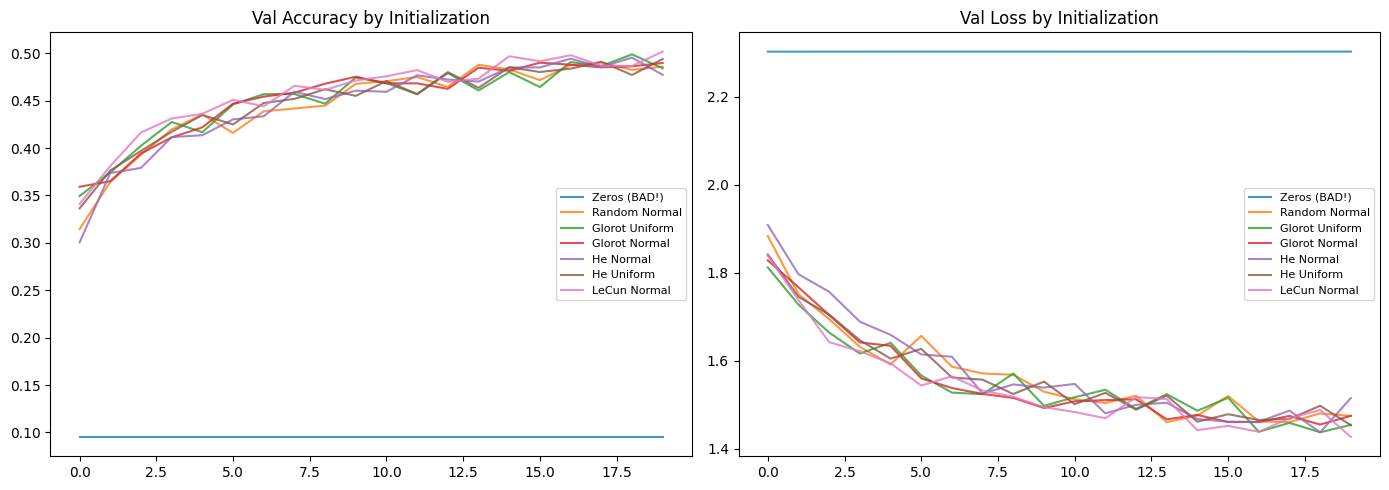

In [3]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in results.items():
    axes[0].plot(h.history['val_accuracy'], label=name, alpha=0.8)
    axes[1].plot(h.history['val_loss'], label=name, alpha=0.8)
axes[0].set_title('Val Accuracy by Initialization'); axes[0].legend(fontsize=8)
axes[1].set_title('Val Loss by Initialization'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Visualize Activation Distributions
Let's see how different initializations affect the distribution of activations in a deep network.

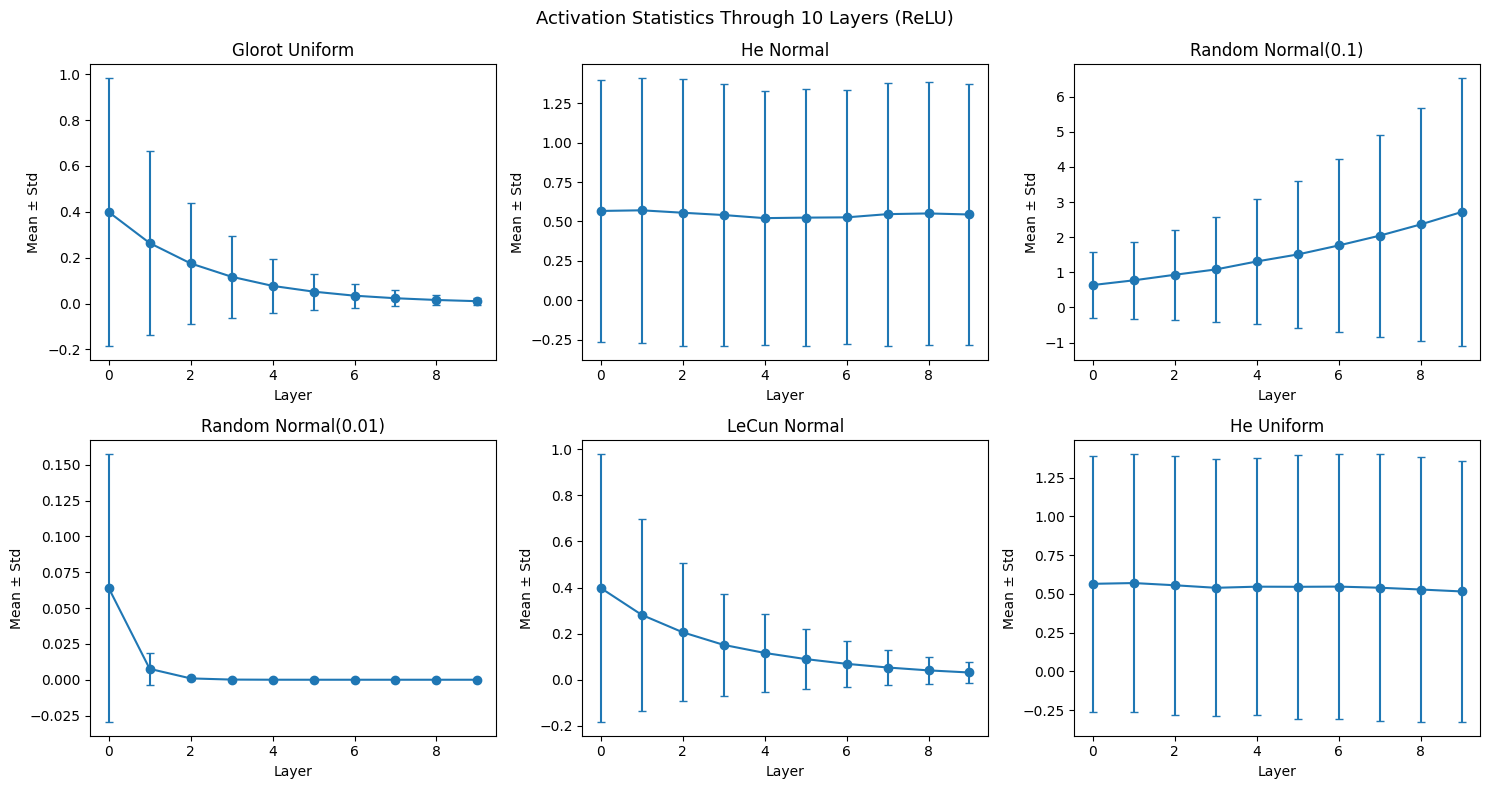

In [4]:
# Show activation distribution through layers
def get_activations(init, n_layers=10):
    """Build a deep network and check activation distribution."""
    x = np.random.randn(1000, 256).astype(np.float32)
    activations = []
    for i in range(n_layers):
        layer = layers.Dense(256, activation='relu', kernel_initializer=init)
        x = layer(x).numpy()
        activations.append(x)
    return activations

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, init) in zip(axes.flat, [
    ('Glorot Uniform', initializers.GlorotUniform()),
    ('He Normal', initializers.HeNormal()),
    ('Random Normal(0.1)', initializers.RandomNormal(stddev=0.1)),
    ('Random Normal(0.01)', initializers.RandomNormal(stddev=0.01)),
    ('LeCun Normal', initializers.LecunNormal()),
    ('He Uniform', initializers.HeUniform()),
]):
    acts = get_activations(init)
    means = [a.mean() for a in acts]
    stds = [a.std() for a in acts]
    ax.errorbar(range(10), means, yerr=stds, fmt='o-', capsize=3)
    ax.set_title(f'{name}'); ax.set_xlabel('Layer'); ax.set_ylabel('Mean ± Std')
plt.suptitle('Activation Statistics Through 10 Layers (ReLU)', fontsize=13)
plt.tight_layout(); plt.show()

## PyTorch Initialization

PyTorch kaiming: Final acc = 0.5047
PyTorch xavier: Final acc = 0.5027
PyTorch zeros: Final acc = 0.1000
PyTorch orthogonal: Final acc = 0.5050


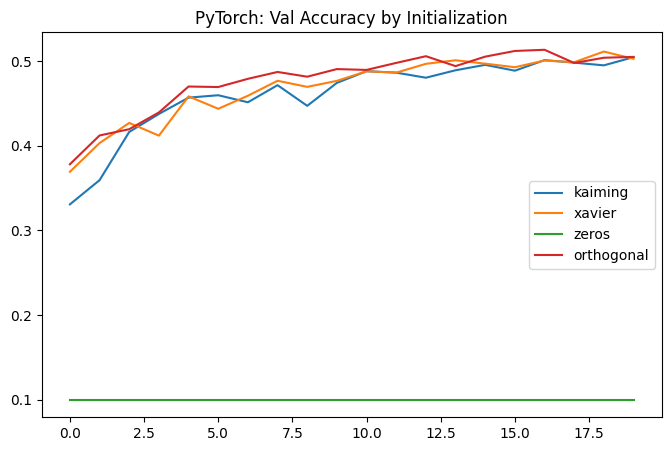

In [5]:
# PyTorch: Apply different initializations
def init_weights(m, method='kaiming'):
    if isinstance(m, nn.Linear):
        if method == 'kaiming': nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        elif method == 'xavier': nn.init.xavier_normal_(m.weight)
        elif method == 'zeros': nn.init.zeros_(m.weight)
        elif method == 'orthogonal': nn.init.orthogonal_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_train_flat), torch.LongTensor(y_train)),
    batch_size=256, shuffle=True)

pt_results = {}
for method in ['kaiming', 'xavier', 'zeros', 'orthogonal']:
    model = nn.Sequential(
        nn.Linear(3072, 256), nn.ReLU(),
        nn.Linear(256, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 10)).to(device)
    model.apply(lambda m: init_weights(m, method))
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    accs = []
    for ep in range(20):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            xt = torch.FloatTensor(X_test_flat).to(device)
            yt = torch.LongTensor(y_test).to(device)
            accs.append((model(xt).argmax(1)==yt).float().mean().item())
    pt_results[method] = accs
    print(f"PyTorch {method}: Final acc = {accs[-1]:.4f}")

plt.figure(figsize=(8, 5))
for name, accs in pt_results.items():
    plt.plot(accs, label=name)
plt.title('PyTorch: Val Accuracy by Initialization'); plt.legend(); plt.show()

## Practical Guidelines
- **ReLU / Leaky ReLU** → Use **He initialization** (default in most frameworks)
- **Sigmoid / Tanh** → Use **Glorot/Xavier initialization**
- **SELU** → Use **LeCun initialization**
- **RNNs** → Use **Orthogonal initialization**
- **Never** initialize weights to all zeros (symmetry breaking problem)
- When in doubt, He Normal for ReLU networks is a safe default